In [81]:
pokemones = open('pokemones.txt', 'r').read().split('\n')       

In [82]:
print(len(pokemones)); print(min(len(pokemon) for pokemon in pokemones)); print(max(len(pokemon) for pokemon in pokemones))

1351
3
27


En este ejemplo estamos creando un diccionario que almacena la cantidad de veces que aparece cada bigrama, pero para un mejor rendimiento
y uso mas profesional, usaremos una matriz (tensor) de 28x28 (porque tenemos 28 caracteres + 1 especiales) 
para almacenar la cantidad de veces que aparece cada bigrama.

```python
b = {}
for p in pokemones:
    chs = ['<S>'] + list(p) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
```

In [83]:
b = {}
for p in pokemones:
    chs = ['<S>'] + list(p) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [84]:
ch = []
for p in pokemones:
    for c in p:
        ch.append(c)
print(len(set(ch)))

27


In [85]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('a', 'r'), 212),
 (('a', '<E>'), 202),
 (('e', '<E>'), 192),
 (('g', 'a'), 167),
 (('<S>', 's'), 165),
 (('r', 'a'), 163),
 (('i', 'n'), 163),
 (('m', 'e'), 160),
 (('o', 'r'), 151),
 (('a', 'l'), 147),
 (('m', 'a'), 144),
 (('l', 'e'), 143),
 (('a', 'n'), 140),
 (('l', 'a'), 135),
 (('o', 'n'), 131),
 (('r', 'o'), 130),
 (('-', 'm'), 128),
 (('<S>', 'm'), 126),
 (('e', 'r'), 123),
 (('e', 'g'), 118),
 (('r', '<E>'), 115),
 (('r', 'i'), 115),
 (('n', '<E>'), 110),
 (('<S>', 'c'), 108),
 (('c', 'h'), 98),
 (('r', 'e'), 97),
 (('<S>', 'g'), 95),
 (('o', 'l'), 95),
 (('l', 'i'), 94),
 (('e', 'l'), 93),
 (('t', 'e'), 93),
 (('<S>', 'p'), 91),
 (('l', 'o'), 91),
 (('t', 'a'), 90),
 (('t', '<E>'), 87),
 (('t', 'o'), 82),
 (('<S>', 't'), 82),
 (('<S>', 'd'), 81),
 (('s', 't'), 80),
 (('d', 'e'), 78),
 (('i', 's'), 78),
 (('e', '-'), 78),
 (('a', 't'), 77),
 (('u', 'r'), 75),
 (('i', 'l'), 73),
 (('m', 'i'), 70),
 (('<S>', 'b'), 67),
 (('y', '<E>'), 67),
 (('n', 'i'), 67),
 (('h', 'i'), 67)

In [86]:
import torch

In [87]:
N = torch.zeros((28, 28), dtype=torch.int32) # Utilizamos int32 porque lo usamos para contar cosas, no necesitamos decimales

In [88]:
print(len(set(''.join(pokemones))))
chars = sorted(list(set(''.join(pokemones))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0 # El numero asignado a los caracteres especiales dependera de la cantidad de caracteres que tenga el dataset
itos = {i:s for s,i in stoi.items()}

27


In [89]:
for pokemon in pokemones:
    chs = ['.'] + list(pokemon) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

# Matriz de conteo de bigramas

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

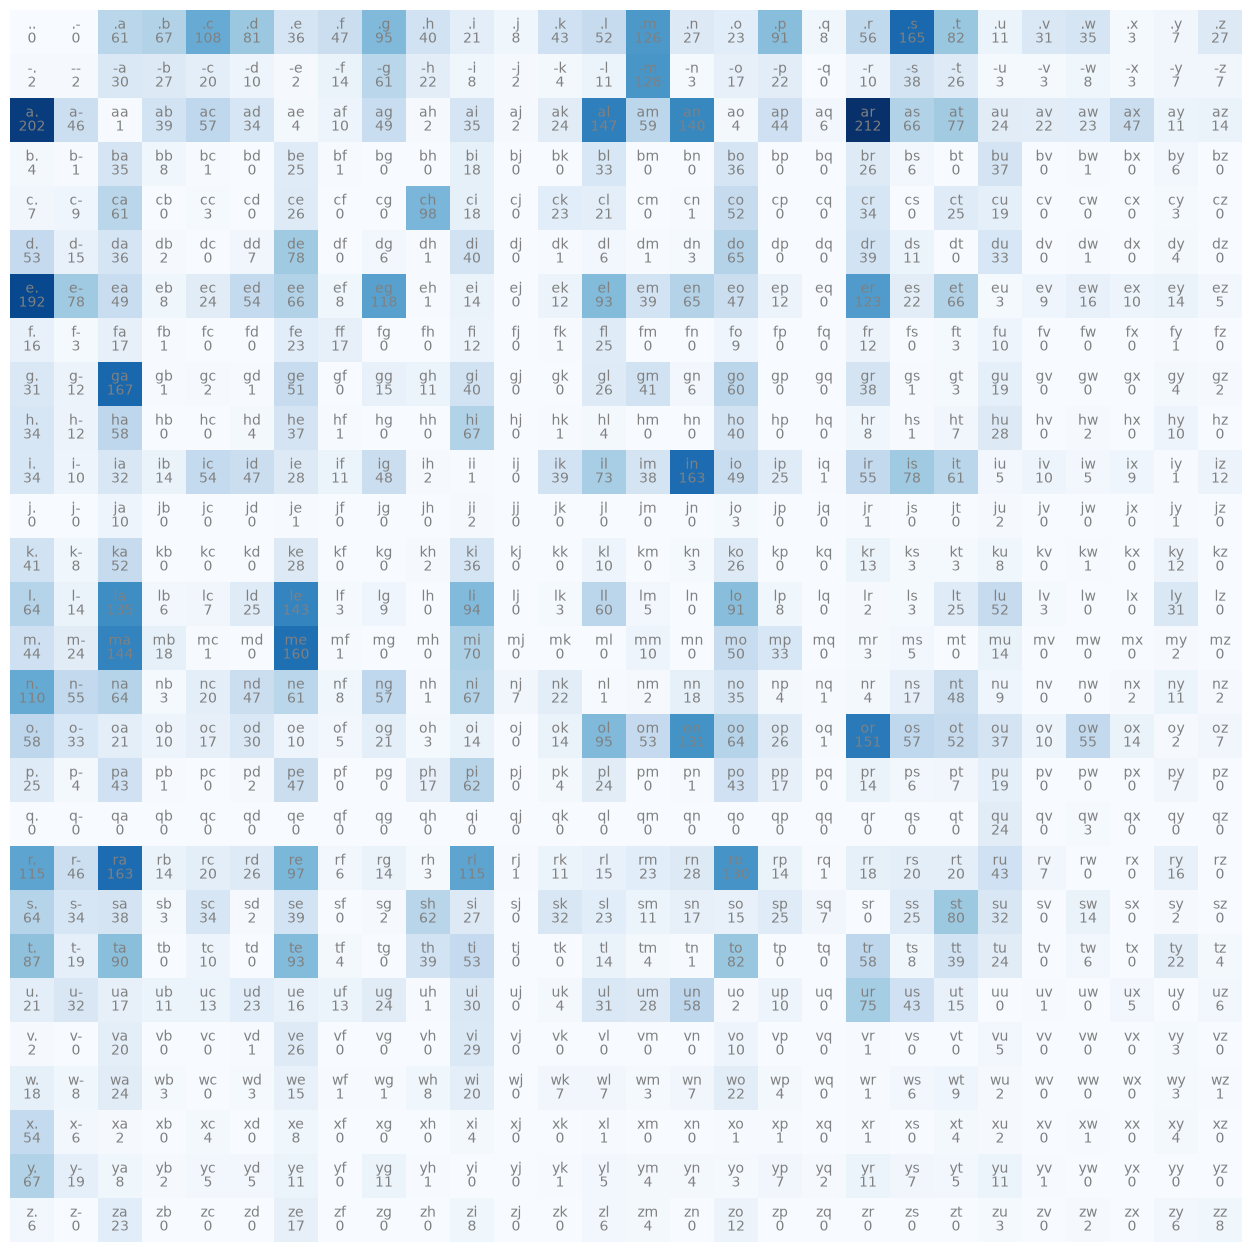

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='gray')
plt.axis('off')

# Normalizacion por renglon
Normalizamos para obtener las probabilidades de que salga un caracter dado otro, normalizamos las filas porque representan el caracter inicial y del cual dependeran los siguientes.
Las columnas representan el segundo caracter del bigrama

In [91]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.0000, 0.0452, 0.0496, 0.0799, 0.0600, 0.0266, 0.0348, 0.0703,
        0.0296, 0.0155, 0.0059, 0.0318, 0.0385, 0.0933, 0.0200, 0.0170, 0.0674,
        0.0059, 0.0415, 0.1221, 0.0607, 0.0081, 0.0229, 0.0259, 0.0022, 0.0052,
        0.0200])

In [92]:
g = torch.Generator().manual_seed(41)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'b'

In [93]:
g = torch.Generator().manual_seed(41)
p = torch.rand(3, generator=g)
#p = p / p.sum()
p

tensor([0.2364, 0.2266, 0.8005])

In [ ]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g) # Multimodal es una funcion de torch que nos regresa indices de una distribucion de probabilidad, en este caso, la distribucion de probabilidad es p. La funcion nos regresa 20 indices, y como replacement es True, puede regresar el mismo indice mas de una vez.

tensor([1, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2])

In [95]:
N[0].shape

torch.Size([28])

In [110]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

In [111]:
g = torch.Generator().manual_seed(41)

for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix]
        #p = N[ix].float() 
        #p = p / p.sum()
        #p = torch.ones(28) / 28
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

ba.
lkea.
mopsw.
hare-acoshe.
lo.
ha.
fe.
surplimanskazehy.
che.
masoaregonolimitowar.
quno.
olar.
sellikwaty-ta.
t.
daill.
het.
a.
sh.
ge.
vem-ludmirit.


# Maximum Likelihood Estimation
Necesitamos un parametro para medir la efectividad del modelo, para eso utilizaremos el likelihood, que se usa para calcular los mejores parametros.
Usamos logaritmo porque al multiplicar todas las probabilidades nos ira dando un numero muy bajo cercano al cero, con logaritmo evitamos esto ademas de que podemos utilizarlo como sumatoria. 
Buscamos maximizar el logaritmo del likelihood y minimizar el negativo y su promedio

In [114]:
log_likelihood = 0.0
n = 0
for pokemon in pokemones:
    chs = ['.'] + list(pokemon) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'Log Likelihood: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood: {nll:.4f}')
print(f'Average Negative Log Likelihood: {nll/n:.4f}')

Log Likelihood: -37775.0273
Negative Log Likelihood: 37775.0273
Average Negative Log Likelihood: 2.6355
